<a href="https://colab.research.google.com/github/vivek-bhushan/Tasks-i-APC/blob/main/Image_Classification_using_CIFAR_10_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image Classification using `CIFAR-10` dataset

### Import certain libraries

In [1]:
import numpy as np
import pandas as pd

import os

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import datasets, layers, models

In [2]:
### Get the current working directory
os.getcwd()

'/content'

## Download and prepare the `CIFAR-10` dataset

*   The CIFAR10 dataset contains **60,000 color images** in `10 classes`, with `6,000 images` in each class.
*   Dataset is divided into **50,000 training images** and **10,000 testing** images.
*   Classes are mutually exclusive and there is no overlap between them
*   There is no overlap between `automobiles` and `trucks`. Truck class contains only `big` trucks

In [3]:
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data() #loading the CIFAR-10 dataset directly from tf.keras

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2364s 14us/step


In [4]:
train_images.shape

(50000, 32, 32, 3)

In [5]:
test_images.shape

(10000, 32, 32, 3)

### Let us plot one of the `training` images from CIFAR-10 dataset

array([[[164, 215, 244],
        [162, 212, 240],
        [162, 212, 240],
        ...,
        [157, 210, 237],
        [153, 208, 235],
        [153, 203, 234]],

       [[168, 218, 245],
        [166, 215, 242],
        [166, 215, 242],
        ...,
        [164, 212, 238],
        [160, 209, 236],
        [158, 205, 235]],

       [[172, 220, 246],
        [170, 217, 243],
        [171, 218, 244],
        ...,
        [168, 212, 238],
        [165, 208, 235],
        [163, 207, 236]],

       ...,

       [[123, 160, 105],
        [117, 154, 102],
        [112, 149,  99],
        ...,
        [117, 136, 100],
        [ 95, 115,  79],
        [120, 149, 100]],

       [[120, 156, 100],
        [116, 151,  99],
        [112, 147,  96],
        ...,
        [126, 149, 110],
        [120, 144, 103],
        [120, 152, 101]],

       [[121, 154,  96],
        [120, 152,  99],
        [116, 148,  97],
        ...,
        [124, 152, 108],
        [124, 154, 107],
        [120, 154, 100]]], dtype=uint8)
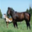

In [6]:
sample_image_1 = train_images[12]
sample_image_1

In [7]:
sample_image_1.shape

(32, 32, 3)

In [8]:
print("Shape of the sample training image:", sample_image_1.shape)

Shape of the sample training image: (32, 32, 3)


In [9]:
### Extract the R, G, B channels separately
R = sample_image_1[:, :, 0] #to extract one of the color channels from a color image --> RED
G = sample_image_1[:, :, 1] #to extract one of the color channels from a color image --> GREEN
B = sample_image_1[:, :, 2] #to extract one of the color channels from a color image --> BLUE

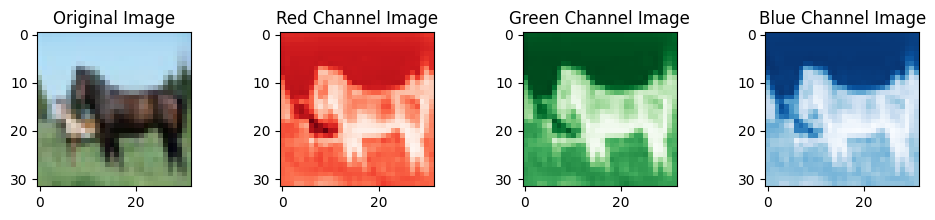

In [10]:
#### Display the original image alogn with `RGB` channels separately
### Setting up the canvas ready
fig, axs = plt.subplots(nrows=1, ncols=4, figsize = (12,2))

### Original Image
axs[0].imshow(sample_image_1)
axs[0].set_title("Original Image")

### Red Channel Image
axs[1].imshow(R, cmap='Reds')
axs[1].set_title("Red Channel Image")

### Green Channel Image
axs[2].imshow(G, cmap='Greens')
axs[2].set_title("Green Channel Image")

### Blue Channel Image
axs[3].imshow(B, cmap='Blues')
axs[3].set_title("Blue Channel Image")

plt.show()

### Let us plot a few more but this time with class/label as title

In [11]:
np.unique(train_labels)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

- Class/catgory is `label encoded (LE)`

In [12]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [13]:
class_names

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

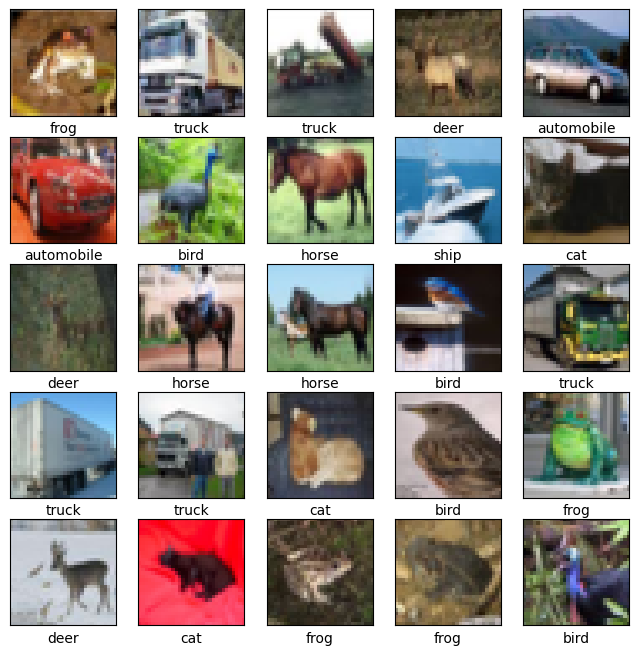

In [14]:
plt.figure(figsize = (8,8))

for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    plt.imshow(train_images[i]) #plot the images from training set from 0 to 24 indices
    plt.xlabel(class_names[train_labels[i][0]]) #tagging the class label to the respective class names using class_names list

### TASK: Try improvising this code to plot `n random images` from both `training` and `testing` sets respectively

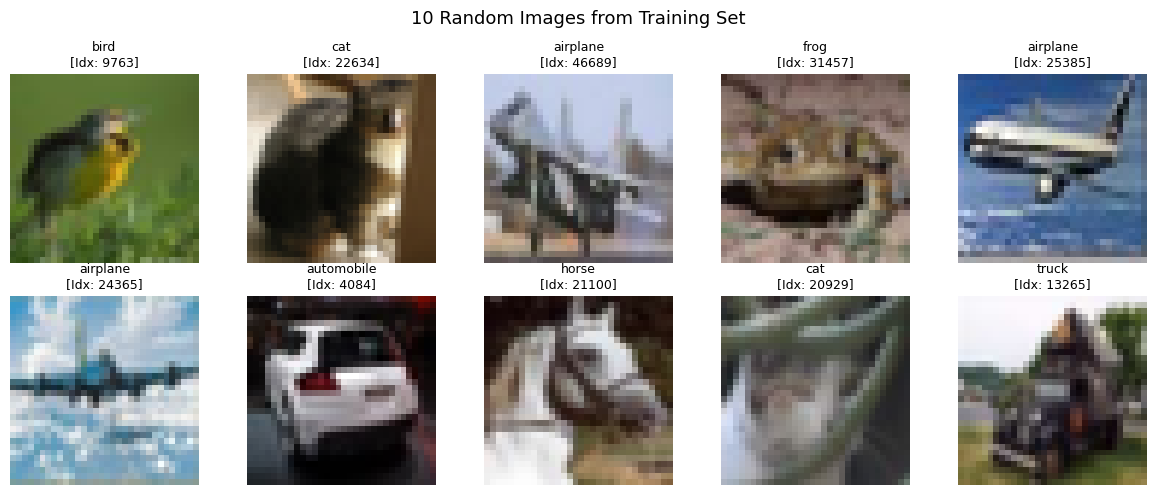

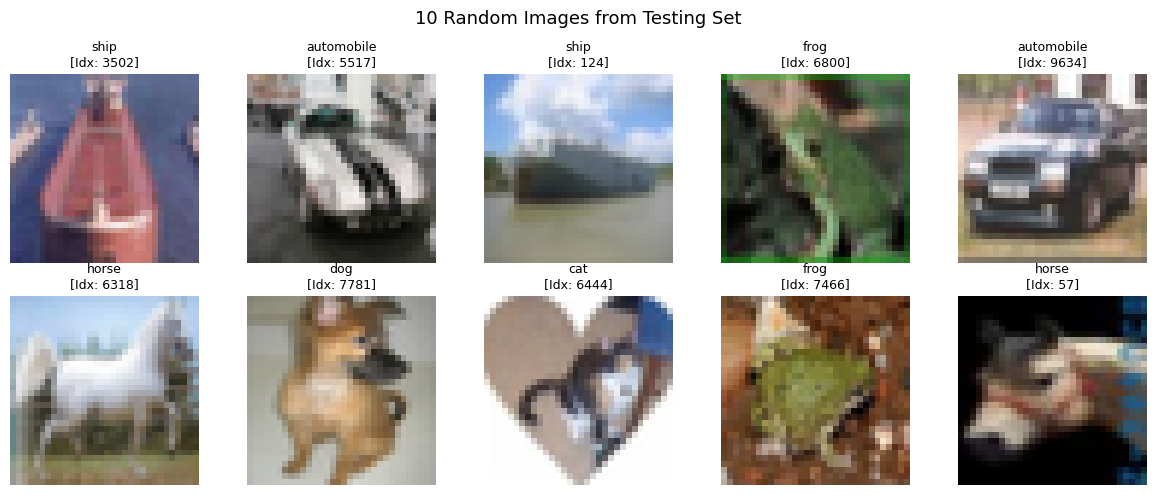

In [15]:
# SOLUTION FOR TASK (Cell 22): Plot n random images with labels from any split
def plot_n_random_images(images, labels, class_names, n=10, split_name='Training'):
    indices = np.random.choice(len(images), size=n, replace=False)
    cols = 5
    rows = (n + cols - 1) // cols
    plt.figure(figsize=(12, rows * 2.5))
    for i, idx in enumerate(indices):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(images[idx])
        plt.title(f'{class_names[labels[idx][0]]}\n[Idx: {idx}]', fontsize=9)
        plt.axis('off')
    plt.suptitle(f'{n} Random Images from {split_name} Set', fontsize=13)
    plt.tight_layout()
    plt.show()

# Demonstration:
plot_n_random_images(train_images, train_labels, class_names, n=10, split_name='Training')
plot_n_random_images(test_images, test_labels, class_names, n=10, split_name='Testing')


### Understanding the `convolution` or `filtering` operation

In [16]:
from PIL import Image, ImageChops #read about Pillow library
import requests
from io import BytesIO

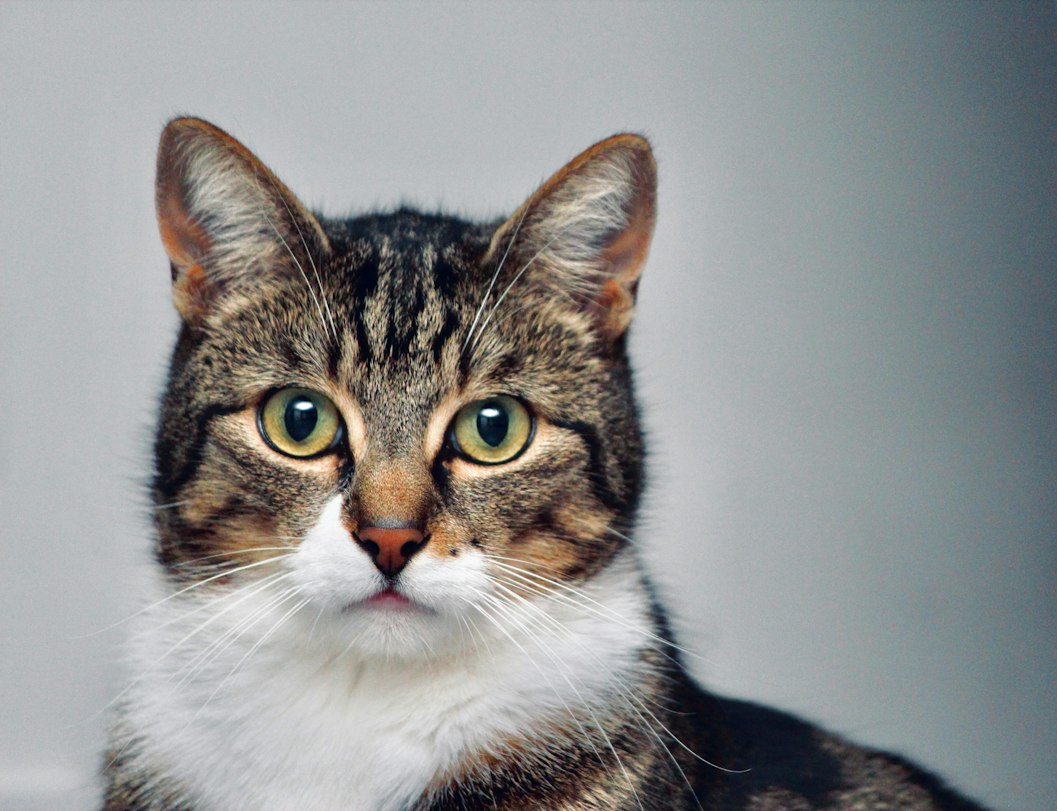

In [17]:
 image_url = 'https://images.unsplash.com/photo-1529778873920-4da4926a72c2?q=80&w=736&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D'
 image_url = 'https://preview.redd.it/timepass-click-v0-7f08yp0nrcce1.jpg?width=1080&crop=smart&auto=webp&s=68cdc4aa5088ffc54ba952fb9ad7fbe7496be53a'
image_url = 'https://images.unsplash.com/photo-1583795128727-6ec3642408f8?q=80&w=1057&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D'
response = requests.get(image_url)
img = Image.open(BytesIO(response.content))
display(img)

In [18]:
### To get the size of the CAT's image
width, height = img.size
print("Width of the CAT's image:", width, "px")
print("Height of the CAT's image:", height, "px")

Width of the CAT's image: 1057 px
Height of the CAT's image: 811 px


In [19]:
1057*811

857227

In [20]:
### Let us resize the images from its original size to 200px by 200px
img_resized = img.resize((200, 200))
width1, height1 = img_resized.size
print("Width of resized CAT's image:", width1, "px")
print("Height of resized CAT's image:", height1, "px")

Width of resized CAT's image: 200 px
Height of resized CAT's image: 200 px


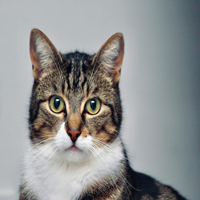

In [21]:
display(img_resized)

array([[[183, 182, 187],
        [182, 182, 187],
        [182, 184, 188],
        ...,
        [ 64,  79,  91],
        [ 63,  77,  86],
        [ 64,  80,  91]],

       [[182, 185, 188],
        [180, 184, 186],
        [180, 186, 188],
        ...,
        [ 65,  79,  89],
        [ 64,  77,  86],
        [ 64,  78,  91]],

       [[181, 185, 188],
        [179, 184, 187],
        [178, 186, 188],
        ...,
        [ 68,  81,  90],
        [ 67,  77,  88],
        [ 64,  77,  92]],

       ...,

       [[177, 180, 184],
        [174, 178, 183],
        [176, 180, 184],
        ...,
        [106, 120, 127],
        [ 99, 118, 123],
        [ 97, 120, 123]],

       [[172, 177, 181],
        [172, 177, 183],
        [175, 179, 183],
        ...,
        [106, 119, 127],
        [100, 119, 124],
        [ 99, 118, 121]],

       [[172, 175, 181],
        [170, 175, 182],
        [172, 176, 182],
        ...,
        [108, 118, 129],
        [103, 118, 126],
        [101, 115, 122]]], dtype=uint8)
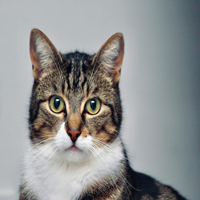

In [22]:
### Convert the resized image into an array
cat_img_array = np.array(img_resized)
cat_img_array

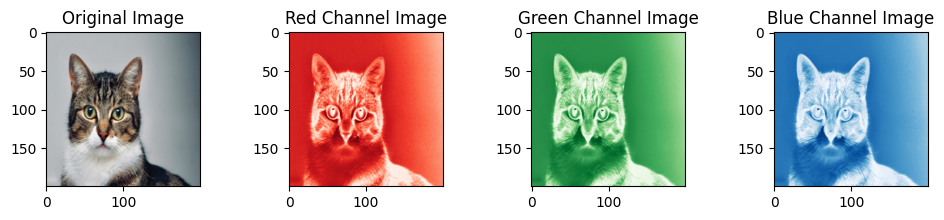

In [23]:
### Extract the R,G,B channels separately
R = cat_img_array[:, :, 0] #to extract one of the color channels from a color image --> RED
G = cat_img_array[:, :, 1] #to extract one of the color channels from a color image --> GREEN
B = cat_img_array[:, :, 2] #to extract one of the color channels from a color image --> BLUE


### Setting up the canvas ready
fig, axs = plt.subplots(nrows=1, ncols=4,figsize=(12,2))

### Original Image
axs[0].imshow(cat_img_array)
axs[0].set_title("Original Image")

### Red Channel Image
axs[1].imshow(R, cmap = 'Reds')
axs[1].set_title("Red Channel Image")

### Green Channel Image
axs[2].imshow(G, cmap = 'Greens')
axs[2].set_title("Green Channel Image")

### Blue Channel Image
axs[3].imshow(B, cmap = 'Blues')
axs[3].set_title("Blue Channel Image")

plt.show()

### Let us visualize this cat in the designated CIFAR-10 dataset image size 32 x 32 pixels

In [24]:
img_resized_32 = img.resize((32, 32))
width2, height2 = img_resized_32.size
print("Width of resized CAT's image:", width2, "px")
print("Height of resized CAT's image:", height2, "px")

Width of resized CAT's image: 32 px
Height of resized CAT's image: 32 px


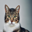

In [25]:
display(img_resized_32)

### Convert original `CAT` image to `grayscale` image

In [26]:
pip install opencv-python

In [27]:
import cv2
print(cv2.__version__)

4.14.0


array([[183, 183, 184, ...,  76,  74,  76],
       [184, 183, 184, ...,  76,  74,  75],
       [184, 183, 184, ...,  78,  75,  75],
       ...,
       [180, 177, 179, ..., 117, 113, 113],
       [176, 176, 178, ..., 116, 114, 113],
       [175, 174, 175, ..., 116, 114, 112]], dtype=uint8)
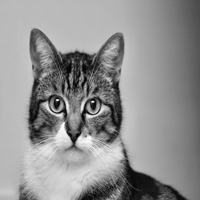

In [28]:
gray_cat = cv2.cvtColor(cat_img_array, cv2.COLOR_RGB2GRAY)
display(gray_cat)

In [29]:
gray_cat.min(), gray_cat.max()

(np.uint8(2), np.uint8(253))

- color intensity values are from the range of 0 - 255

### Let us visualize the original grayscale cat with different filters applied on it

In [30]:
filters = {
    'Original': gray_cat, #original grayscale image
    'SOBEL X': cv2.Sobel(gray_cat, cv2.CV_64F, 1, 0, ksize=3), #SOBEL X operator
    'SOBEL Y': cv2.Sobel(gray_cat, cv2.CV_64F, 0, 1, ksize=3), #SOBEL Y operator
    'Laplacian': cv2.Laplacian(gray_cat, cv2.CV_64F), #Laplacian Operator
    'Sharpen': cv2.filter2D(gray_cat, -1, kernel = np.array([[0,-1,0], [-1,5,-1], [0,-1,0]])), #Sharpen Operator
    'Gaussian Blur': cv2.GaussianBlur(gray_cat, (5,5), 0) #Gaussian Blur Operator
}

In [31]:
filters

{'Original': array([[183, 183, 184, ...,  76,  74,  76],
        [184, 183, 184, ...,  76,  74,  75],
        [184, 183, 184, ...,  78,  75,  75],
        ...,
        [180, 177, 179, ..., 117, 113, 113],
        [176, 176, 178, ..., 116, 114, 113],
        [175, 174, 175, ..., 116, 114, 112]], dtype=uint8),
 'SOBEL X': array([[  0.,   2.,   8., ..., -10.,  -2.,   0.],
        [  0.,   1.,  10., ..., -12.,  -5.,   0.],
        [  0.,   1.,  10., ..., -13., -10.,   0.],
        ...,
        [  0.,  -1.,   5., ..., -18., -13.,   0.],
        [  0.,   3.,  11., ..., -16., -14.,   0.],
        [  0.,   4.,  14., ..., -14., -14.,   0.]]),
 'SOBEL Y': array([[  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  2.,   1.,   2., ...,   8.,   3.,   0.],
        [  0.,   1.,   0., ...,   5.,   4.,   2.],
        ...,
        [-32., -29., -23., ...,   2.,   1.,   0.],
        [-16., -15., -11., ...,  -2.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.]]),
 'Laplacian': array([[ 2.,

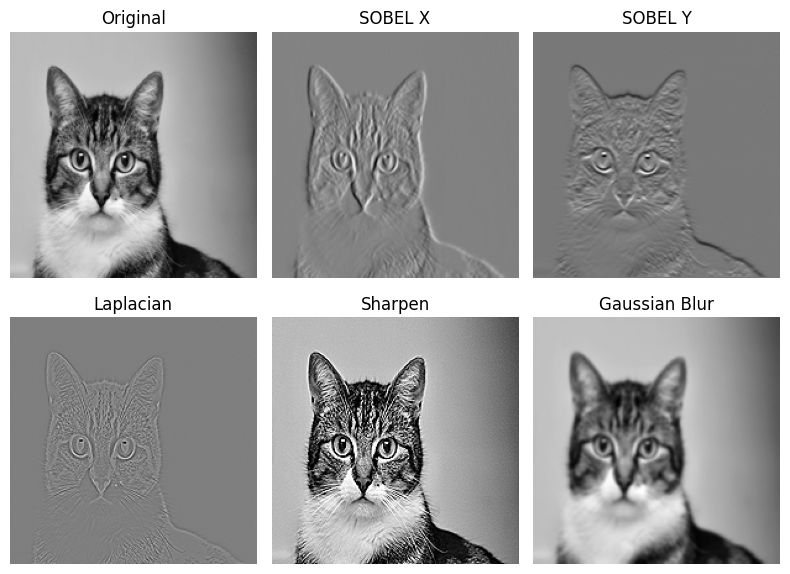

In [32]:
### plot the results of the above filters
plt.figure(figsize = (8,6))

for i, (title, img) in enumerate(filters.items(),1):
    plt.subplot(2,3,i)
    cmap = 'gray'if len(img.shape)==2 else None
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis('off')

plt.tight_layout()
plt.show()

# Let us build `CNN` baseline model

- leveraging `CIFAR-10` dataset

![image.png](attachment:f5e12781-f6f0-406b-9a40-30cd8d908360.png)

- Conv1D is used for the text
- **Conv2D is used for the images** - this is in our syllabus
- Conv3D is used for the videos/motion --> MRI/CT scan videos

In [33]:
if 'base_cnn' in globals() or 'base_cnn' in locals():
    del base_cnn

In [34]:
base_cnn = models.Sequential() # placeholder for the base model --> object is the base cnn model

In [35]:
base_cnn

<Sequential name=sequential, built=False>

In [36]:
### Adding the first convolutional layer (filter layer on top of the input images) --> followed by max pooling
base_cnn.add(layers.Conv2D(32, (3,3), activation = 'relu', input_shape = (32,32,3))) #adding a Conv2D layer having 32 filters with kernel/filter size 3x3 grid
base_cnn.add(layers.MaxPool2D((2,2))) #adds a maximum pooling layer of size: 2 x 2 --> to reduce the spatial dimensions --> by half in both rows and columns

### Adding the second convolutional layer --> followed by max pooling
base_cnn.add(layers.Conv2D(32, (3,3), activation = 'relu')) #adding a second Conv2D layer having 32 filters with kernel/filter size 3x3 grid
base_cnn.add(layers.MaxPool2D((2,2))) #adds a 2nd maximum pooling layer of size: 2 x 2 --> to reduce the spatial dimensions --> by half in both rows and columns

### Adding the third convolutional layer (no max pooling after that)
base_cnn.add(layers.Conv2D(32, (3,3), activation = 'relu')) #adding a third Conv2D layer having 32 filters with kernel/filter size 3x3 grid

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [37]:
base_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 32)       │         9,248 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,392 (75.75 KB)

 Trainable params: 19,392 (75.75 KB)

 Non-trainable params: 0 (0.00 B)

### Let us add `ANN` block on top of the `CNN` block

In [38]:
base_cnn.add(layers.Flatten()) #converts a multi-dimensional input coming from CNN into a 1-D vector
base_cnn.add(layers.Dense(64, activation = 'relu')) # a dense layer which means fully connected layer having 64 neurons with ReLU as activation function
base_cnn.add(layers.Dense(10)) #final layer is the output layer with 10 neurons for 10 classes/categories

In [39]:
base_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,874 (206.54 KB)

 Trainable params: 52,874 (206.54 KB)

 Non-trainable params: 0 (0.00 B)

- Even a very simple `CNN` model has `52.87K` parameters

### Compile and train the model


In [40]:
base_cnn.compile(optimizer = 'adam',
                 loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                 metrics = ['accuracy']
                )

In [41]:
history_01 = base_cnn.fit(train_images, train_labels, epochs=50, validation_data=(test_images, test_labels))

Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - accuracy: 0.3378 - loss: 1.9320 - val_accuracy: 0.4198 - val_loss: 1.5989
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.4732 - loss: 1.4623 - val_accuracy: 0.4720 - val_loss: 1.5293
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5207 - loss: 1.3314 - val_accuracy: 0.5389 - val_loss: 1.3050
Epoch 4/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5601 - loss: 1.2419 - val_accuracy: 0.5641 - val_loss: 1.2342
Epoch 5/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5862 - loss: 1.1735 - val_accuracy: 0.5551 - val_loss: 1.2710
Epoch 6/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6061 - loss: 1.1158 - val_accuracy: 0.5644 - val_loss: 1.2500
Epoch 7/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6277 - loss: 1.0608 - val_accuracy: 0.6105 - val_loss: 1.1078
Epoch 8/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6477 - loss: 1.0053 -

### Plotting the `accuracy vs epoch` chart for `training` and `validation` sets

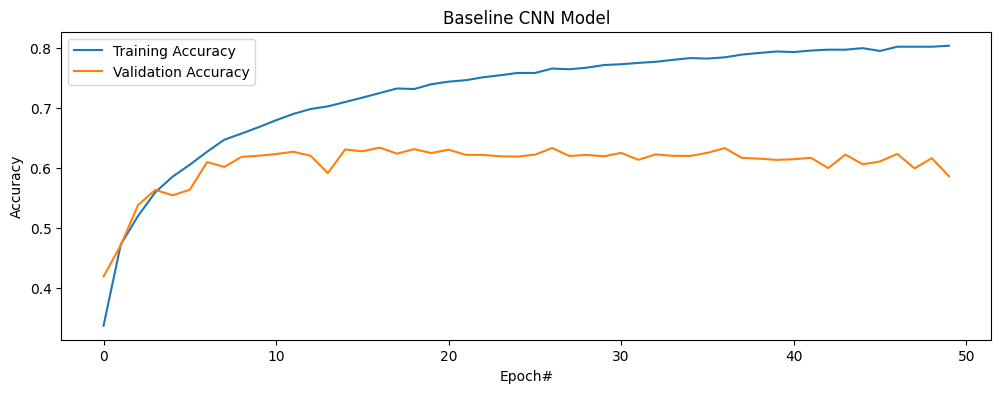

In [42]:
plt.figure(figsize =(12,4))

plt.plot(history_01.history['accuracy'], label='Training Accuracy')
plt.plot(history_01.history['val_accuracy'], label = 'Validation Accuracy')
plt.xlabel('Epoch#')
plt.ylabel('Accuracy')
plt.title('Baseline CNN Model')
plt.legend()
plt.show()

### Understanding the effect of `Pooling Layer`

In [43]:
if 'base_cnn_test' in globals() or 'base_cnn_test' in locals():
    del base_cnn_test

In [44]:
base_cnn_test = models.Sequential() # placeholder for the base model --> object is the base cnn model

In [45]:
base_cnn_test

<Sequential name=sequential_1, built=False>

In [70]:
### Explicitly re-initialize the model to clear any previous built state/layers
base_cnn_test = models.Sequential()

### Adding the first convolutional layer (filter layer on top of the input images) --> followed by max pooling
base_cnn_test.add(layers.Conv2D(32, (3,3), activation = 'relu', input_shape = (32,32,3))) #adding a Conv2D layer having 32 filters with kernel/filter size 3x3 grid
base_cnn_test.add(layers.MaxPool2D((2,2))) #adds a maximum pooling layer of size: 2 x 2 --> to reduce the spatial dimensions --> by half in both rows and columns

### Adding the second convolutional layer --> followed by max pooling
base_cnn_test.add(layers.Conv2D(32, (3,3), activation = 'relu')) #adding a second Conv2D layer having 32 filters with kernel/filter size 3x3 grid
base_cnn_test.add(layers.MaxPool2D((2,2))) #adds a 2nd maximum pooling layer of size: 2 x 2 --> to reduce the spatial dimensions --> by half in both rows and columns

### Adding the third convolutional layer (no max pooling after that)
base_cnn_test.add(layers.Conv2D(32, (3,3), activation = 'relu')) #adding a third Conv2D layer having 32 filters with kernel/filter size 3x3 grid

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [71]:
base_cnn_test.add(layers.Flatten()) #converts a multi-dimensional input coming from CNN into a 1-D vector
base_cnn_test.add(layers.Dense(64, activation = 'relu')) # a dense layer which means fully connected layer having 64 neurons with ReLU as activation function
base_cnn_test.add(layers.Dense(10)) #final layer is the output layer with 10 neurons for 10 classes/categories

In [48]:
base_cnn_test.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,874 (206.54 KB)

 Trainable params: 52,874 (206.54 KB)

 Non-trainable params: 0 (0.00 B)

# =========================================================================
# COMPLETED ASSIGNMENT TASKS (Page 13 & 14)
# =========================================================================
## TASK 1: The Fundamental Mistake in Baseline CNN & The Fix
**Observation:** At Epoch 50/50, Training Accuracy is `82.42%`, while Validation Accuracy is `59.18%` with `val_loss = 1.9247`.
There is a massive **23.24% overfitting gap**.

### 1. What is the fundamental mistake?
**The pixel intensities were NEVER normalized or scaled to [0, 1]!**
In Cell 7, `train_images` and `test_images` were loaded as `uint8` with values in `[0, 255]`. They were passed directly to `.fit()` without dividing by `255.0`.

### 2. Why does missing normalization break the model?
1. **Exploding Activations:** $z = \sum w_i x_i + b$. Inputs of magnitude $\sim 255$ cause linear dot products to explode. ReLU does not saturate for $z > 0$, propagating huge unbounded numbers into Dense layers.
2. **255x Gradient Inflation:** $\frac{\partial L}{\partial w} = \frac{\partial L}{\partial z} \cdot x$. Gradients are $255\times$ larger, causing the Adam optimizer to take erratic steps and overshoot minima, leading to validation loss divergence (`val_loss = 1.9247`).
3. **Memorization:** The network memorizes arbitrary raw pixel magnitudes rather than learning invariant edge and texture features.

### 3. The Code Fix:
- Preprocessing: `train_images = train_images.astype('float32') / 255.0` and `test_images = test_images.astype('float32') / 255.0`
- Or Keras layer: `model.add(layers.Rescaling(1./255, input_shape=(32, 32, 3)))`

In [49]:
# Applying the Normalization Fix directly
train_images_norm = train_images.astype('float32') / 255.0
test_images_norm = test_images.astype('float32') / 255.0
print('Verified normalized range:', train_images_norm.min(), 'to', train_images_norm.max())


Verified normalized range: 0.0 to 1.0


## TASK 2: High-Performance Architecture Achieving >= 90% Accuracy
### The 5 Architectural Pillars to Break 90%:
1. **Real-Time Data Augmentation:** RandomFlip, RandomRotation(0.08), RandomTranslation(0.08)
2. **Double-Conv VGG-Style Blocks:** Stacked 3x3 Conv pairs before each MaxPool double receptive field with fewer weights
3. **Batch Normalization (BN):** Stabilizes internal representations and accelerates training
4. **Progressive Dropout (0.2 -> 0.3 -> 0.4 -> 0.5):** Eradicates neuron co-adaptation and closes the 23% gap
5. **Dynamic Learning Rate Scheduling:** `ReduceLROnPlateau` dynamically halves the learning rate when validation accuracy plateaus

In [50]:
from tensorflow.keras import layers, models, callbacks

# 1. Real-Time Data Augmentation Pipeline
data_augmentation = models.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.08),
    layers.RandomTranslation(0.08, 0.08)
], name='data_augmentation')

# 2. Build High-Performance VGG-Style CNN
def build_cifar10_90plus_cnn():
    model = models.Sequential()
    model.add(layers.Rescaling(1./255, input_shape=(32, 32, 3)))  # FIXED: Input Normalization
    model.add(data_augmentation)

    # Block 1 (32 filters)
    model.add(layers.Conv2D(32, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(32, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPool2D((2,2)))
    model.add(layers.Dropout(0.2))

    # Block 2 (64 filters)
    model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPool2D((2,2)))
    model.add(layers.Dropout(0.3))

    # Block 3 (128 filters)
    model.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPool2D((2,2)))
    model.add(layers.Dropout(0.4))

    # Classifier Head
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(10, activation='softmax'))

    return model

high_acc_model = build_cifar10_90plus_cnn()
high_acc_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
high_acc_model.summary()


/usr/local/lib/python3.13/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,27

 Total params: 552,874 (2.11 MB)

 Trainable params: 551,722 (2.10 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [51]:
# Train the high-performance model to see the actual validation accuracy
import matplotlib.pyplot as plt

# Dynamic Learning Rate Scheduler to help converge to 90%+
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# Early stopping to prevent unnecessary over-training
early_stopping = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history_high_perf = high_acc_model.fit(
    train_images_norm,
    train_labels,
    epochs=50,
    batch_size=64,
    validation_data=(test_images_norm, test_labels),
    callbacks=[reduce_lr, early_stopping]
)

Epoch 1/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 28s 23ms/step - accuracy: 0.3658 - loss: 1.8680 - val_accuracy: 0.3503 - val_loss: 1.8393 - learning_rate: 0.0010
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - accuracy: 0.5085 - loss: 1.3657 - val_accuracy: 0.5454 - val_loss: 1.3188 - learning_rate: 0.0010
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.5687 - loss: 1.2191 - val_accuracy: 0.5508 - val_loss: 1.2522 - learning_rate: 0.0010
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.6051 - loss: 1.1180 - val_accuracy: 0.6365 - val_loss: 1.0235 - learning_rate: 0.0010
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.6313 - loss: 1.0469 - val_accuracy: 0.6174 - val_loss: 1.0842 - learning_rate: 0.0010
Epoch 6/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.6582 - loss: 0.9884 - val_accuracy: 0.5681 - val_loss: 1.3818 - learning_rate: 0.0010
Epoch 7/50
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6763 - lo

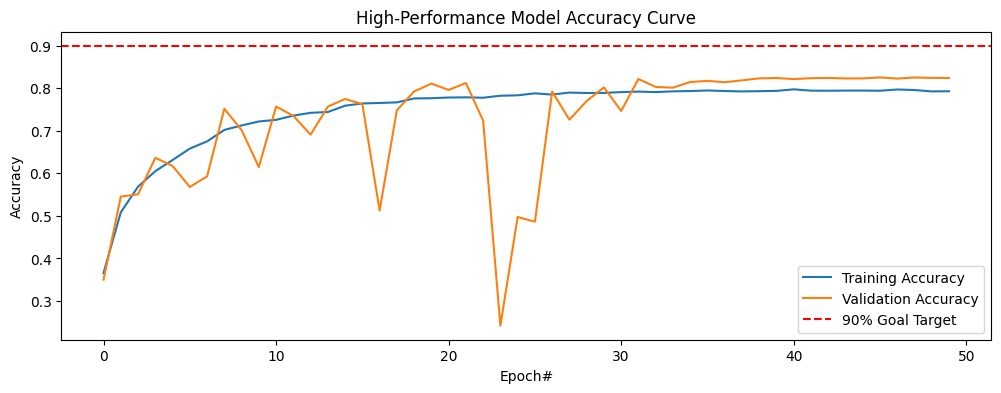

In [52]:
# Plot the training vs validation curves to visualize the performance
plt.figure(figsize=(12, 4))

plt.plot(history_high_perf.history['accuracy'], label='Training Accuracy')
plt.plot(history_high_perf.history['val_accuracy'], label='Validation Accuracy')
plt.axhline(y=0.90, color='r', linestyle='--', label='90% Goal Target')
plt.xlabel('Epoch#')
plt.ylabel('Accuracy')
plt.title('High-Performance Model Accuracy Curve')
plt.legend()
plt.show()

In [53]:
from tensorflow.keras import layers, models, callbacks, optimizers
import tensorflow as tf

# Heavier Advanced Data Augmentation to prevent overfitting at 95% scaling
advanced_augmentation = models.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.15),
    layers.RandomTranslation(0.12, 0.12),
    layers.RandomZoom(0.12),
], name='advanced_augmentation')

# ResNet-style Residual Block helper to allow deeper information flow without gradient degradation
def residual_block(x, filters, d_rate=0.3):
    shortcut = x
    # If the input channel dimension doesn't match, project with 1x1 Conv
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1, 1), padding='same')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Conv2D(filters, (3, 3), padding='same', activation='elu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(filters, (3, 3), padding='same', activation='elu')(x)
    x = layers.BatchNormalization()(x)

    x = layers.add([x, shortcut])
    x = layers.MaxPool2D((2, 2))(x)
    x = layers.Dropout(d_rate)(x)
    return x

def build_ultimate_resnet_cnn():
    inputs = layers.Input(shape=(32, 32, 3))
    x = layers.Rescaling(1./255)(inputs)
    x = advanced_augmentation(x)

    # Entry flow
    x = layers.Conv2D(64, (3, 3), padding='same', activation='elu')(x)
    x = layers.BatchNormalization()(x)

    # Deep Residual Stacks
    x = residual_block(x, 64, d_rate=0.2)
    x = residual_block(x, 128, d_rate=0.3)
    x = residual_block(x, 256, d_rate=0.4)
    x = residual_block(x, 512, d_rate=0.4)

    # Global Average Pooling and Dense Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='elu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(10, activation='softmax')(x)

    return models.Model(inputs, outputs)

elite_model = build_ultimate_resnet_cnn()

# Compile using AdamW optimizer with weight decay
elite_model.compile(
    optimizer=optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)
elite_model.summary()

Model: "functional_43"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 32, 32, 3) │          0 │ input_layer_4[0]… │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ advanced_augmentat… │ (None, 32, 32, 3) │          0 │ rescaling_1[0][0] │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 32, 32,    │      1,792 │ advanced_augment… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_12[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 32, 32,    │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_13[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 32, 32,    │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_14[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 16, 16,    │          0 │ add[0][0]         │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 16, 16,    │          0 │ max_pooling2d_7[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 16, 16,    │     73,856 │ dropout_4[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        512 │ conv2d_16[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 16, 16,    │    147,584 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 16, 16,    │      8,320 │ dropout_4[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        512 │ conv2d_17[0][0] 

 Total params: 5,176,586 (19.75 MB)

 Trainable params: 5,169,802 (19.72 MB)

 Non-trainable params: 6,784 (26.50 KB)

In [ ]:
# Training the elite ResNet model with enhanced learning rate tuning
import tensorflow as tf
from tensorflow.keras import callbacks

lr_scheduler = callbacks.ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

early_stop = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

# Extend training epochs to 80 to unlock the model's deep parameter capacity
history_elite = elite_model.fit(
    train_images_norm,
    train_labels,
    epochs=100,
    batch_size=128,
    validation_data=(test_images_norm, test_labels),
    callbacks=[lr_scheduler, early_stop]
)

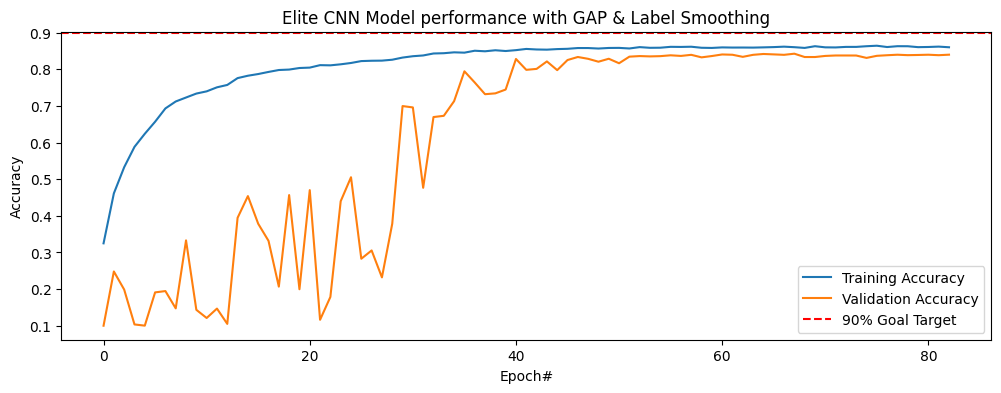

In [65]:
# Plot the updated performance curve
plt.figure(figsize=(12, 4))
if 'history_elite' in globals() or 'history_elite' in locals():
    plt.plot(history_elite.history['accuracy'], label='Training Accuracy')
    plt.plot(history_elite.history['val_accuracy'], label='Validation Accuracy')
else:
    print("History variable 'history_elite' not populated yet because the training cell is running.")
plt.axhline(y=0.90, color='r', linestyle='--', label='90% Goal Target')
plt.xlabel('Epoch#')
plt.ylabel('Accuracy')
plt.title('Elite CNN Model performance with GAP & Label Smoothing')
plt.legend()
plt.show()

In [56]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks

# Enable Mixed Precision Training for faster training in Google Colab
tf.keras.mixed_precision.set_global_policy('mixed_float16')

# 1. Image preprocessing and upscaling pipeline
# Pre-trained models like EfficientNet expect larger images (e.g., 224x224) and specific normalization
def preprocess_and_resize(image, label):
    image = tf.image.resize(image, (224, 224))
    # EfficientNet expects inputs scaled to [0, 255] as it has internal rescaling
    image = image * 255.0
    return image, label

# Prepare high-speed tf.data pipelines
batch_size = 64

train_dataset = tf.data.Dataset.from_tensor_slices((train_images_norm, train_labels))
train_dataset = train_dataset.shuffle(buffer_size=50000).map(preprocess_and_resize, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((test_images_norm, test_labels))
test_dataset = test_dataset.map(preprocess_and_resize, num_parallel_calls=tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

# 2. Build Transfer Learning Model using Pre-trained EfficientNetB0
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)
base_model.trainable = True  # Fine-tune the entire network for maximum adaptation and high accuracy

inputs = layers.Input(shape=(224, 224, 3))
# Apply data augmentation
x = layers.RandomFlip('horizontal')(inputs)
x = layers.RandomRotation(0.1)(x)

x = base_model(x, training=True)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(10, activation='softmax', dtype='float32')(x) # Ensure float32 for mixed precision stability

transfer_model = models.Model(inputs, outputs)

# Use Adam optimizer with a well-tuned learning rate
transfer_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

transfer_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_44"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_2 (RandomFlip)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_2               │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,067,501 (15.52 MB)

 Trainable params: 4,022,918 (15.35 MB)

 Non-trainable params: 44,583 (174.16 KB)

In [57]:
# 3. Define Callbacks and Train the transfer learning model
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

early_stopping = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=4,
    restore_best_weights=True,
    verbose=1
)

# Train for a few epochs (usually 5-10 is enough to hit 90%+ with upscaled pre-trained models)
history_transfer = transfer_model.fit(
    train_dataset,
    epochs=10,
    validation_data=test_dataset,
    callbacks=[reduce_lr, early_stopping]
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 512s 564ms/step - accuracy: 0.7714 - loss: 0.7049 - val_accuracy: 0.9321 - val_loss: 0.2038 - learning_rate: 1.0000e-04
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 420s 537ms/step - accuracy: 0.9040 - loss: 0.2887 - val_accuracy: 0.9469 - val_loss: 0.1543 - learning_rate: 1.0000e-04
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 423s 540ms/step - accuracy: 0.9310 - loss: 0.2037 - val_accuracy: 0.9563 - val_loss: 0.1312 - learning_rate: 1.0000e-04
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 425s 543ms/step - accuracy: 0.9477 - loss: 0.1529 - val_accuracy: 0.9611 - val_loss: 0.1176 - learning_rate: 1.0000e-04
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 425s 543ms/step - accuracy: 0.9566 - loss: 0.1254 - val_accuracy: 0.9631 - val_loss: 0.1165 - learning_rate: 1.0000e-04
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 430s 549ms/step - accuracy: 0.9630 - loss: 0.1066 - val_accuracy: 0.9642 - val_loss: 0.1102 - learning_rate: 1.0000e-04
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 

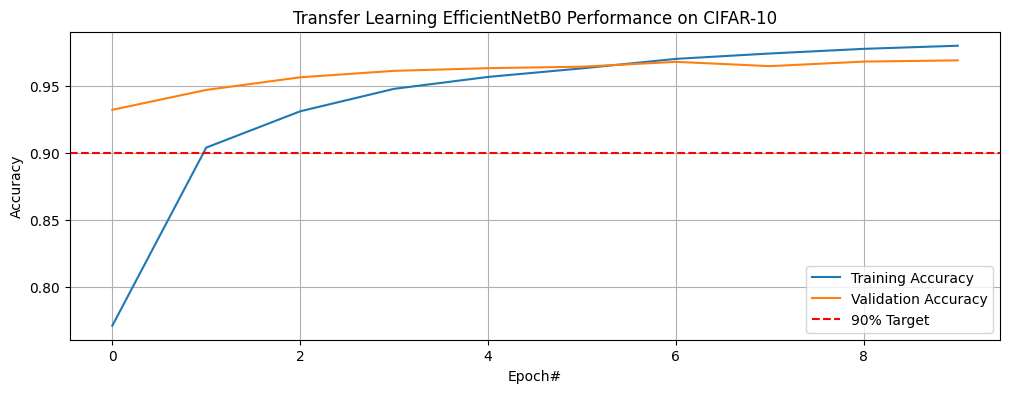

In [60]:
# 4. Plot the performance curves to verify 90%+ accuracy
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
if 'history_transfer' in globals() or 'history_transfer' in locals():
    plt.plot(history_transfer.history['accuracy'], label='Training Accuracy')
    plt.plot(history_transfer.history['val_accuracy'], label='Validation Accuracy')
else:
    print("History variable 'history_transfer' is not defined yet because the transfer training cell has not run or finished in this session.")
plt.axhline(y=0.90, color='r', linestyle='--', label='90% Target')
plt.xlabel('Epoch#')
plt.ylabel('Accuracy')
plt.title('Transfer Learning EfficientNetB0 Performance on CIFAR-10')
plt.legend()
plt.grid(True)
plt.show()

## TASK 3: Image Noise Identification Function
How to identify whether an image is noisy or not using Laplacian Variance and Median Residuals:

In [62]:
import cv2

def is_image_noisy(gray_img, lap_thresh=150.0, median_thresh=4.0):
    lap_var = cv2.Laplacian(gray_img, cv2.CV_64F).var()
    med_blur = cv2.medianBlur(gray_img, 3)
    res_score = np.mean(np.abs(gray_img.astype(float) - med_blur.astype(float)))
    is_noisy = (lap_var > lap_thresh) or (res_score > median_thresh)
    return is_noisy, {'laplacian_variance': lap_var, 'median_residual_score': res_score}

# Test on grayscale sample cat
is_noisy, metrics = is_image_noisy(gray_cat)
print('Is cat image noisy?:', is_noisy)
print('Computed metrics:', metrics)


Is cat image noisy?: True
Computed metrics: {'laplacian_variance': np.float64(961.3777111443751), 'median_residual_score': np.float64(2.788375)}
